In [1]:
from pymongo import MongoClient
import pandas as pd
from sklearn.linear_model import LinearRegression      # 머신러닝 리니어리그레션 모델

# MongoDB 연결

In [3]:
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]

train_collection = db["train_data"]
predict_collection = db["prediction_result"]

In [4]:
# 샘플 데이터 저장

sample_data = [
    {"temperature":70, "pressure":100, "vibration":0.10, "quality_score":80},
    {"temperature":75, "pressure":110, "vibration":0.15, "quality_score":85},
    {"temperature":80, "pressure":120, "vibration":0.20, "quality_score":88},
    {"temperature":85, "pressure":130, "vibration":0.25, "quality_score":90},
    {"temperature":90, "pressure":140, "vibration":0.30, "quality_score":92},
    {"temperature":95, "pressure":150, "vibration":0.35, "quality_score":95},
    {"temperature":96, "pressure":155, "vibration":0.36, "quality_score":96},
    {"temperature":99, "pressure":165, "vibration":0.40, "quality_score":98}
]

train_collection.delete_many({})            # 기존 데이터 삭제
train_collection.insert_many(sample_data)   # 새로 데이터 insert

InsertManyResult([ObjectId('6a7be688be04a4127b6c3a5f'), ObjectId('6a7be688be04a4127b6c3a60'), ObjectId('6a7be688be04a4127b6c3a61'), ObjectId('6a7be688be04a4127b6c3a62'), ObjectId('6a7be688be04a4127b6c3a63'), ObjectId('6a7be688be04a4127b6c3a64'), ObjectId('6a7be688be04a4127b6c3a65'), ObjectId('6a7be688be04a4127b6c3a66')], acknowledged=True)

In [7]:
# MongoDB 읽기
df = pd.DataFrame(
    list(train_collection.find())
)
# _id 컬럼 제거
if "_id" in df.columns:
    df = df.drop("_id", axis=1)

df

,temperature,pressure,vibration,quality_score
0,70,100,0.10,80
1,75,110,0.15,85
2,80,120,0.20,88
3,85,130,0.25,90
4,90,140,0.30,92
5,95,150,0.35,95
6,96,155,0.36,96
7,99,165,0.40,98


In [8]:
# 학습 데이터 설정 및 학습 수행
X = df[[
        "temperature",
        "pressure",
        "vibration"
    ]]

y = df["quality_score"]

model = LinearRegression()  # 학습 모델 정의
model.fit(X,y)              # 학습 수행

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# ai 추론(예측)   <-- inference

# 신규 데이터 입력
new_data = pd.DataFrame(
    [{
        "temperature": 82,
        "pressure":125,
        "vibration":0.22
    }]
)

# 예측 수행
pred = model.predict(new_data)[0]

print("예측결과: ", pred)

예측결과:  88.08888888888889


In [11]:
# ai 결과 저장
predict_collection.insert_one(
    {
        "temperature": 82,
        "pressure":125,
        "vibration":0.22,
        "predicted_quality":float(pred)
    }
)

InsertOneResult(ObjectId('6a7bec1cbe04a4127b6c3a67'), acknowledged=True)

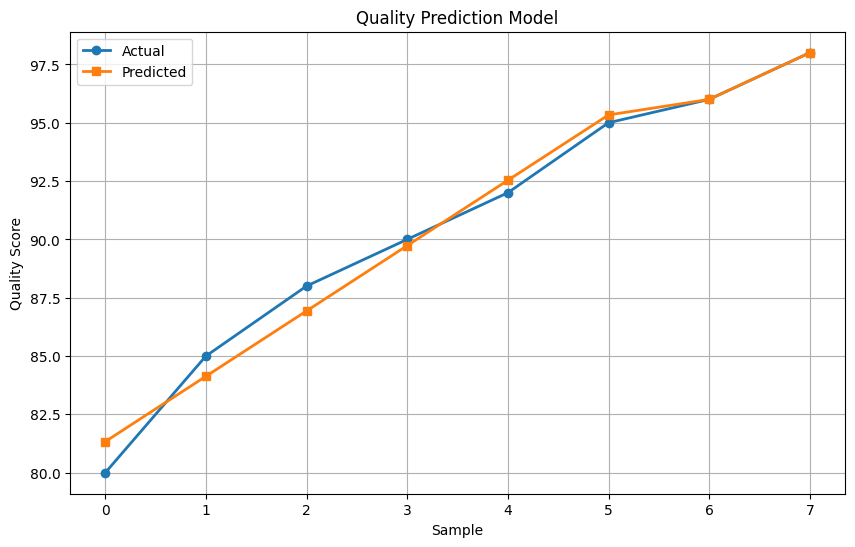

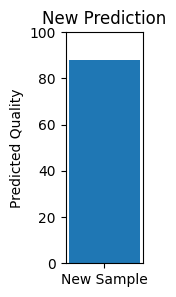

In [12]:
# 시각화

import matplotlib.pyplot as plt

# 학습 데이터 예측
y_pred = model.predict(X)

plt.figure(figsize=(10,6))

# 실제값
plt.plot(
    y.values,
    marker='o',
    linewidth=2,
    label='Actual'
)

# 예측값
plt.plot(
    y_pred,
    marker='s',
    linewidth=2,
    label='Predicted'
)

plt.title("Quality Prediction Model")
plt.xlabel("Sample")
plt.ylabel("Quality Score")

plt.legend()
plt.grid(True)

plt.show()

# 신규 예측 결과
plt.figure(figsize=(1,3))

plt.bar(
    ["New Sample"],
    [pred]
)

plt.title("New Prediction")
plt.ylabel("Predicted Quality")

plt.ylim(0,100)

plt.show()

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# 학습 데이터 예측
y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("="*50)
print("모델 성능")
print("="*50)
print(f"MAE  : {mae:.4f}")   # 평균 절대 오차
print(f"MSE  : {mse:.4f}")   # Mean Squared Error 평균 제곱오차
print(f"RMSE : {rmse:.4f}")  # Root Mean Squared Error 평균 제곱근 오차
print(f"R²   : {r2:.4f}")    # 결정계수 (설명력, 1과 가까울수록 좋음)

모델 성능
MAE  : 0.5500
MSE  : 0.5167
RMSE : 0.7188
R²   : 0.9839


Text(0, 0.5, 'Residual')

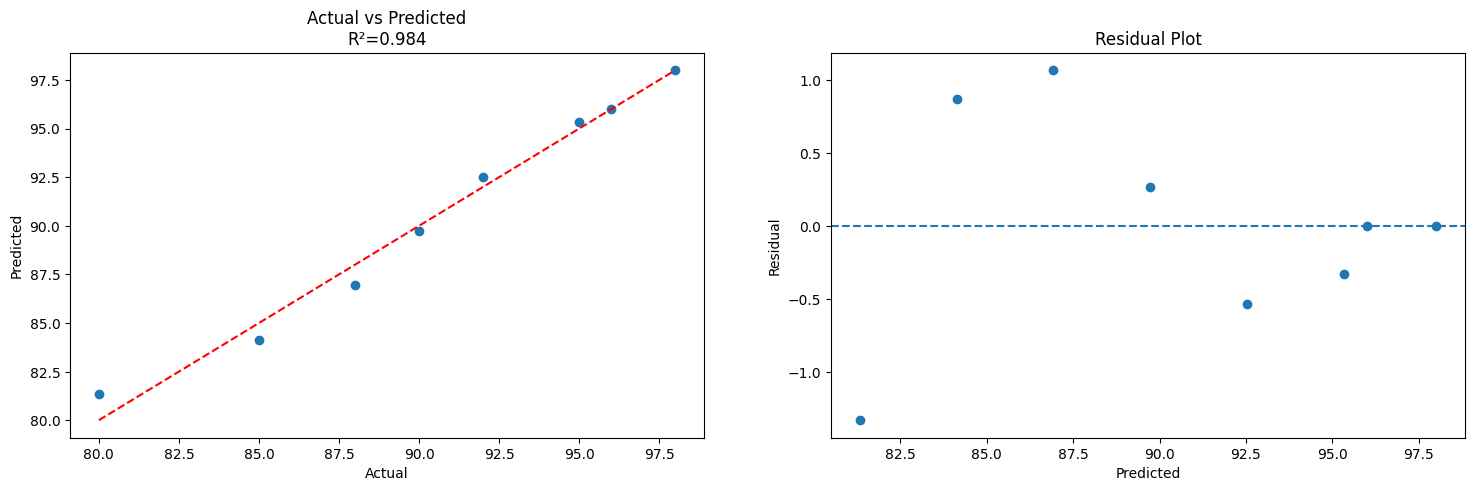

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,5)
)

# ------------------
# Actual vs Predicted
# ------------------

axes[0].scatter(y, y_pred)

axes[0].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

axes[0].set_title(
    f'Actual vs Predicted\nR²={r2:.3f}'
)

axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# ------------------
# Residual
# ------------------

residuals = y - y_pred

axes[1].scatter(
    y_pred,
    residuals
)

axes[1].axhline(
    y=0,
    linestyle='--'
)

axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')